# CEE 299 Report : Analysis of Unsupervised Clusters in the Building Inventory

## Introduction
Regional-scale building inventories are high-dimensional and heterogeneous, posing challenges for understanding structural vulnerability patterns. This study explores unsupervised clustering of a large building inventory to identify structurally and physically meaningful groupings without reliance on damage or loss labels. We apply and compare two clustering approaches, hard assignment of the points to clusters through K-means and soft/probabilistic assignment through Gaussian Mixture Models (GMMs). Using this we partition buildings based on key geometric, structural, and site-related attributes.

Through clustering and subsequent analysis, we aim to address the following three problems:
1. How many meaningful clusters exist in the building inventory, and how can this number be determined?
2. Which features are the primary drivers of unsupervised cluster separation in the building inventory?
3. Does the labeled subset exhibit systematic patterns across the identified clusters?
---

#### Code Blocks: Importing the libraries and dataset

In [2]:
import keras

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import seaborn as sns



shared_notebook_dir = "G:/Shared drives/CS229 Project"
current_notebook_dir = pathlib.Path().resolve()
dir = pathlib.Path(shared_notebook_dir) / "Code" / "For_Model_Training"
# Check NumPy version
import numpy as np
print(f"Current NumPy version: {np.__version__}")
print(current_notebook_dir)

Current NumPy version: 2.3.5
C:\Users\varun\OneDrive - Stanford\Desktop\Stanford\5. Autumn 25 Quarter\Independent Study CEE299\Code


In [4]:
# import data from Code\For_Model_Training
X_train = pd.read_pickle(dir / "X_train.pkl")
y_train = pd.read_pickle(dir / "y_train.pkl")
X_validation = pd.read_pickle(dir / "X_validation.pkl")
y_validation = pd.read_pickle(dir / "y_validation.pkl")
X_test = pd.read_pickle(dir / "X_test.pkl")
y_test = pd.read_pickle(dir / "y_test.pkl")
x_unlabelled = pd.read_pickle(dir / "X_unlabelled.pkl")

In [5]:
assert list(X_train.columns) == list(X_validation.columns) == list(X_test.columns) == list(x_unlabelled.columns)
print(np.shape(x_unlabelled), np.shape(X_train), np.shape(X_validation), np.shape(X_test))

(2022433, 13) (173, 13) (23, 13) (35, 13)


In [7]:
n_train = len(X_train)
n_val   = len(X_validation)
n_test  = len(X_test)
n_unlab = len(x_unlabelled)

idx_train = slice(0, n_train)
idx_val   = slice(n_train, n_train + n_val)
idx_test  = slice(n_train + n_val, n_train + n_val + n_test)
idx_unlab = slice(n_train + n_val + n_test, None)

print("Index slices:")
print("Train:", idx_train)
print("Validation:", idx_val)
print("Test:", idx_test)
print("Unlabelled:", idx_unlab)

Index slices:
Train: slice(0, 173, None)
Validation: slice(173, 196, None)
Test: slice(196, 231, None)
Unlabelled: slice(231, None, None)


In [8]:
X_all = pd.concat(
    [X_train, X_validation, X_test, x_unlabelled],
    axis=0,
    ignore_index=True
)

print("X_all shape:", X_all.shape)
print("Total rows check:", n_train + n_val + n_test + n_unlab)

X_all shape: (2022664, 13)
Total rows check: 2022664


In [9]:
if isinstance(X_all, pd.DataFrame):
    assert not X_all.isna().any().any()
    assert np.isfinite(X_all.values).all()
else:
    assert np.isfinite(X_all).all()

In [11]:
X_all_np = X_all.values if isinstance(X_all, pd.DataFrame) else X_all
rng = np.random.default_rng(19)

subsample_size = min(100000, X_all_np.shape[0])
sub_idx = rng.choice(X_all_np.shape[0], size=subsample_size, replace=False)

X_sub = X_all_np[sub_idx]

---

## Problem 1. Number of Meaningful Clusters 

### Clustering Evaluation Metrics 
To determine an appropriate number of clusters and assess clustering quality, we evaluated multiple complementary metrics that capture different geometric aspects of the clustering structure. All geometric metrics were computed in the original feature space using Euclidean distance. No single clustering metric fully characterizes cluster quality, as point-level separation, global variance structure, and worst-case cluster overlap reflect distinct and complementary properties that may favor different numbers of clusters.

Accordingly, we jointly considered the Silhouette Score, Calinski–Harabasz index, and Davies–Bouldin index to obtain a more robust and balanced assessment of clustering quality and to reduce bias toward any single criterion when selecting the number of clusters for k-means. In addition, for Gaussian Mixture Models (GMMs), which provide a probabilistic description of the data, we also evaluated likelihood-based model selection criteria, specifically the Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC), to complement the geometric metrics.

The definitions of each are provided below-
##### (i) Silhouette Score
For a data point $i$:
$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}
$$
where
$$
a(i) = \frac{1}{|C(i)| - 1}
\sum_{\substack{j \in C(i) \\ j \neq i}} d(x_i, x_j)
$$
$$
b(i) =
\min_{C \neq C(i)}
\left(
\frac{1}{|C|}
\sum_{j \in C} d(x_i, x_j)
\right)
$$
here:
- $C(i)$: cluster containing point $i$ 
- $|C|$: size of cluster C 
- $d(\cdot,\cdot)$: Euclidean distance

**Interpretation**

The silhouette score measures how well a point fits within its assigned cluster compared to the nearest alternative cluster.  
Higher values indicate better point-level separation, while values near zero indicate overlapping clusters.

##### (ii) Calinski–Harabasz (CH) Index

$$
\mathrm{CH}(K) =
\frac{
\displaystyle
\frac{1}{K-1}
\sum_{k=1}^{K}
n_k . |\mu_k - \mu|^2
}{
\displaystyle
\frac{1}{N-K}
\sum_{k=1}^{K}
\sum_{x_i \in C_k}
|x_i - \mu_k|^2
}
$$

here:
* $N$: total number of points
* $K$: number of clusters
* $C_k$: set of points in cluster $k$
* $n_k = |C_k|$: number of points in cluster $k$
* $\mu_k$: centroid (mean) of cluster $k$
* $\mu$: global mean of all points
* $|\cdot|$: Euclidean norm

**Interpretation**

The Calinski–Harabasz index measures the ratio of between-cluster dispersion to within-cluster dispersion.
Higher values indicate that cluster centroids explain a larger fraction of the total variance in the data.


##### (iii) Davies–Bouldin (DB) Index
$$
\mathrm{DB}(K) =
\frac{1}{K}
\sum_{i=1}^{K}
\max_{j \neq i}
\left(
\frac{S_i + S_j}{M_{ij}}
\right)
$$
with
$$
S_i =
\frac{1}{n_i}
\sum_{x \in C_i} d(x, \mu_i)
$$
$$
M_{ij} = d(\mu_i, \mu_j)
$$
here:
- $S_i$: average intra-cluster distance (cluster scatter)  
- $M_{ij}$: distance between centroids of clusters $i$ and $j$

**Interpretation**

The Davies–Bouldin index measures the average worst-case similarity between clusters, comparing cluster compactness to centroid separation.  
Lower values indicate more compact and better-separated clusters.

##### (iv) Akaike Information Criterion (AIC) — *GMM only*

$$
\mathrm{AIC} = 2p - 2 \ln(\hat{L})
$$

here:
- $p$: number of free parameters in the GMM  
- $\hat{L}$: maximized likelihood of the data under the model

**Interpretation**

Balances model fit and complexity using likelihood; penalizes models with many parameters.  
Lower AIC indicates a better trade-off between goodness-of-fit and complexity.


##### (v) Bayesian Information Criterion (BIC) — *GMM only*

$$
\mathrm{BIC} = p \ln(N) - 2 \ln(\hat{L})
$$

here:
- $N$: number of data points  
- $p$: number of free parameters  
- $\hat{L}$: maximized likelihood of the data under the model

**Interpretation**

Strongly penalizes model complexity relative to dataset size, favoring simpler models.  
Lower BIC indicates a more parsimonious model and is commonly used to select the number of GMM components.


##### Summary

| Metric | Optimized When | Applicable To | Captures |
|---|---|---|---|
| Silhouette | Higher | Any clustering | Point-level separation |
| Calinski–Harabasz | Higher | Any clustering | Global variance explained |
| Davies–Bouldin | Lower | Any clustering | Worst-case cluster overlap |
| AIC | Lower | GMM | Likelihood vs complexity |
| BIC | Lower | GMM | similar to AIC but stricter on compelxity |

---


### Unsupervised Learning: K-Means 

In [47]:
%load_ext autoreload
%autoreload 2
from cluster_models import *

In [49]:
import importlib
import cluster_models

importlib.reload(cluster_models)
from cluster_models import *

k=  2 | silhouette=0.1654 | CH=16691.0 | DB=2.0088
k=  3 | silhouette=0.1704 | CH=13047.4 | DB=2.1036
k=  4 | silhouette=0.1958 | CH=15594.5 | DB=1.7233
k=  5 | silhouette=0.0932 | CH=13051.9 | DB=1.9506
k=  6 | silhouette=0.1661 | CH=15008.7 | DB=1.5379
k=  7 | silhouette=0.1448 | CH=13862.2 | DB=1.5725
k=  8 | silhouette=0.1571 | CH=13673.0 | DB=1.5056
k=  9 | silhouette=0.1171 | CH=9996.7 | DB=2.0821
k= 10 | silhouette=0.1270 | CH=11879.8 | DB=1.6440
k= 11 | silhouette=0.1255 | CH=11981.7 | DB=1.6555
k= 12 | silhouette=0.1410 | CH=11544.8 | DB=1.7716
k= 13 | silhouette=0.1269 | CH=10856.6 | DB=1.7258
k= 14 | silhouette=0.1303 | CH=10497.5 | DB=1.6770
k= 15 | silhouette=0.1311 | CH=9847.6 | DB=1.7849
k= 16 | silhouette=0.1406 | CH=9375.8 | DB=1.6947
k= 17 | silhouette=0.1148 | CH=8950.8 | DB=1.8474
k= 18 | silhouette=0.1263 | CH=8802.4 | DB=1.7495
k= 19 | silhouette=0.1378 | CH=8429.1 | DB=1.7531


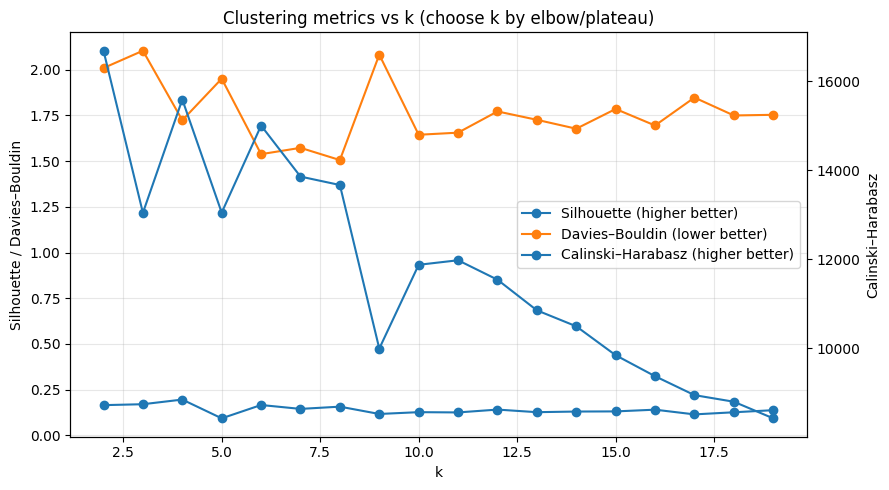

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.165350,16691.008790,2.008842
1,3,0.170386,13047.440860,2.103603
2,4,0.195824,15594.532758,1.723285
3,5,0.093166,13051.937557,1.950649
4,6,0.166088,15008.676545,1.537872
5,7,0.144808,13862.221013,1.572501
6,8,0.157063,13672.972703,1.505643
7,9,0.117078,9996.681522,2.082081
8,10,0.126961,11879.790027,1.644026
9,11,0.125494,11981.709572,1.655457


In [15]:
#Search K
k_values = range(2, 20)
results_df, models = search_optimal_k(
    X_sub,
    k_values,
    batch_size=8192,
    max_iter=300,
    random_state=19,
    silhouette_sample_size=30000,
)

# Plot all metrics vs K
plot_metrics_vs_k(results_df)

# View table
results_df

##### Based on the plot obtained for k-means clustering, **K=6** gives the most optimum number of clusters. 
---

### Unsupervised Learning: Gaussian Mixture Models (GMM)

##### EM Algorithm (Expectation Maximization) for GMMs

We have a dataset $\{x^{(i)}\}_{i=1}^{i=m}$, where each example is a feature vector for a building in the inventory
$$
x^{(i)} \in \mathbb{R}^{n} \quad (\text{here } n=13,\; m \approx 2\times 10^6).
$$

A GMM assumes each $x^{(i)}$ was generated by **one** of $K$ Gaussian components/clusters.
It introduce a latent discrete random variable $z^{(i)} \in \{1,\dots,K\}$ indicating which component/cluster generated $x^{(i)}$.

The latent variable is a multinomial with parameter vector $\phi$ :
$$
z^{(i)} \sim \mathrm{Multinomial}(\phi),
\qquad
\phi = (\phi_1,\dots,\phi_K),\quad \phi_j \ge 0,\quad \sum_{j=1}^K \phi_j = 1.
$$
and
$$
p\!\left(z^{(i)} = j\right)=\phi_j .
$$

-
Given $z^{(i)}=j$, the observed vector is Gaussian:
$$
x^{(i)} \mid \left(z^{(i)}=j\right) \sim \mathcal{N}(\mu_j,\Sigma_j).
$$

and therefore
$$
p\!\left(x^{(i)} \mid z^{(i)}=j;\mu,\Sigma\right)
=
\mathcal{N}\!\left(x^{(i)};\mu_j,\Sigma_j\right).
$$

By marginalizing over $z^{(i)}$:
$$
p\!\left(x^{(i)};\phi,\mu,\Sigma\right)
=
\sum_{j=1}^K
p\!\left(z^{(i)}=j;\phi\right)\,
p\!\left(x^{(i)} \mid z^{(i)}=j;\mu,\Sigma\right)
=
\sum_{j=1}^K
\phi_j\,\mathcal{N}\!\left(x^{(i)};\mu_j,\Sigma_j\right).
$$

EM alternates between computing responsibilities (E-step) and updating parameters (M-step).

**E-step (compute responsibilities)**

Define
$$
w_j^{(i)} \;=\; p\!\left(z^{(i)}=j \mid x^{(i)};\phi,\mu,\Sigma\right).
$$

Using Bayes' rule:
$$
w_j^{(i)}
=
\frac{
p\!\left(x^{(i)} \mid z^{(i)}=j;\mu,\Sigma\right)\,p\!\left(z^{(i)}=j;\phi\right)
}{
\sum_{\ell=1}^K
p\!\left(x^{(i)} \mid z^{(i)}=\ell;\mu,\Sigma\right)\,p\!\left(z^{(i)}=\ell;\phi\right)
}
=
\frac{
\phi_j\,\mathcal{N}\!\left(x^{(i)};\mu_j,\Sigma_j\right)
}{
\sum_{\ell=1}^{K}
\phi_\ell\,\mathcal{N}\!\left(x^{(i)};\mu_\ell,\Sigma_\ell\right)
}.
$$

*Interpretation:* $w_j^{(i)}$ is the probability that component $j$ generated point $x^{(i)}$.


**M-step (update parameters using responsibilities)**

First define the effective number of points assigned to component $j$:
$$
N_j = \sum_{i=1}^{m} w_j^{(i)}.
$$

Update mixture weights:
$$
\phi_j = \frac{N_j}{m}.
$$

Update means:
$$
\mu_j = \frac{1}{N_j}\sum_{i=1}^{m} w_j^{(i)}\,x^{(i)}.
$$

Update covariances:
$$
\Sigma_j
=
\frac{1}{N_j}
\sum_{i=1}^{m}
w_j^{(i)}\left(x^{(i)}-\mu_j\right)\left(x^{(i)}-\mu_j\right)^{\top}.
$$

**Log-likelihood (to monitor convergence)**
$$
\ell(\phi,\mu,\Sigma)
=
\sum_{i=1}^{m}
\log\left(
\sum_{j=1}^{K}
\phi_j\,\mathcal{N}\!\left(x^{(i)};\mu_j,\Sigma_j\right)
\right).
$$

EM guarantees $\ell$ does not decrease after each full E-step + M-step update. (Jensen's Inequality)

**What EM gives out (the main outputs)**

After fitting, you get:
- **Soft assignments / responsibilities** $w_j^{(i)} = p(z^{(i)}=j \mid x^{(i)})$ for every point and component
- Estimated mixture parameters: **weights** $\phi_j$, **means** $\mu_j$, and **covariances** $\Sigma_j$ for each component

**AIC and BIC for GMM**

For a fitted GMM with log-likelihood $\ell(\hat{\phi},\hat{\mu},\hat{\Sigma})$ and $p$ free parameters:

$$
\mathrm{AIC} = 2p - 2\,\ell(\hat{\phi},\hat{\mu},\hat{\Sigma})
$$

$$
\mathrm{BIC} = p\log m - 2\,\ell(\hat{\phi},\hat{\mu},\hat{\Sigma})
$$
$$
\ell(\hat{\phi},\hat{\mu},\hat{\Sigma})
=
\sum_{i=1}^{m}
\log\!\left(
\sum_{j=1}^{K}
\hat{\phi}_j\,\mathcal{N}\!\left(x^{(i)};\hat{\mu}_j,\hat{\Sigma}_j\right)
\right).
$$


##### Working Code - GMM : 

k=  2 | silhouette=0.3162 | CH=6098.0 | DB=2.6439 | BIC=-262021.2 | AIC=-264009.4
k=  3 | silhouette=0.1799 | CH=4833.3 | DB=2.9643 | BIC=-404824.5 | AIC=-407811.5
k=  4 | silhouette=0.1707 | CH=5312.3 | DB=2.5340 | BIC=-525345.7 | AIC=-529331.6
k=  5 | silhouette=0.1106 | CH=5632.2 | DB=2.9633 | BIC=-1525147.6 | AIC=-1530132.4
k=  6 | silhouette=0.0419 | CH=4660.4 | DB=3.0043 | BIC=-1482485.8 | AIC=-1488469.5
k=  7 | silhouette=0.1362 | CH=5441.4 | DB=3.7363 | BIC=-1701269.4 | AIC=-1708251.9
k=  8 | silhouette=0.0731 | CH=6154.7 | DB=2.3812 | BIC=-1624814.6 | AIC=-1632796.0
k=  9 | silhouette=0.0491 | CH=5153.2 | DB=2.6849 | BIC=-2136348.1 | AIC=-2145328.3
k= 10 | silhouette=0.0327 | CH=6027.3 | DB=2.6026 | BIC=-2110730.4 | AIC=-2120709.5
k= 11 | silhouette=0.0394 | CH=6437.0 | DB=2.3203 | BIC=-2155580.7 | AIC=-2166558.7
k= 12 | silhouette=0.0398 | CH=6648.3 | DB=2.3578 | BIC=-2441955.8 | AIC=-2453932.6
k= 13 | silhouette=0.0359 | CH=5504.4 | DB=2.6751 | BIC=-2786609.8 | AIC=-2799585.

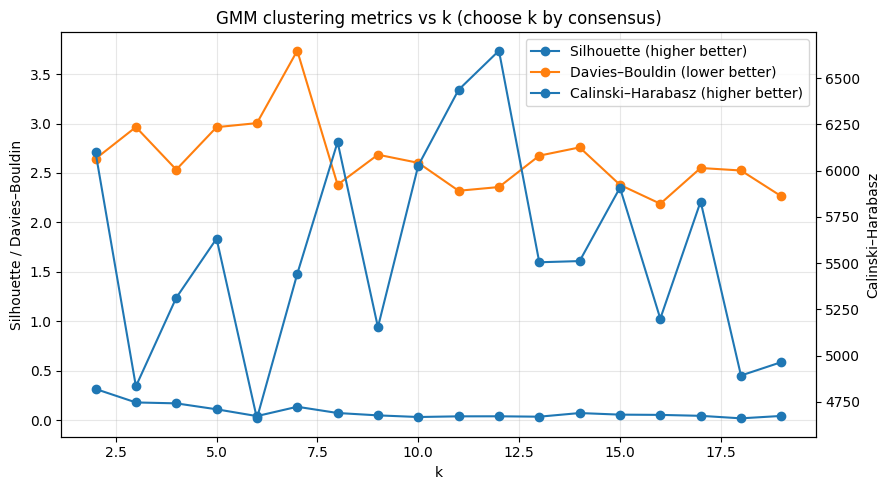

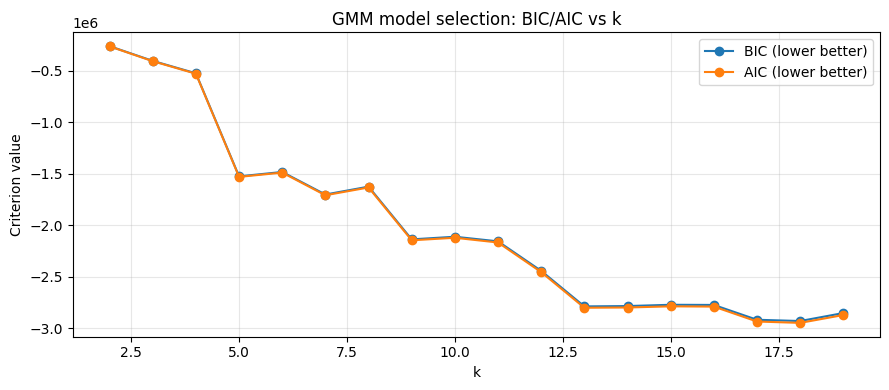

In [50]:
k_values = list(range(2, 20))
results_gmm, models_gmm = search_optimal_k_gmm(
    X_sub,
    k_values,
    covariance_type="full",
    n_init=5,
    random_state=19
)

plot_metrics_vs_k_gmm(results_gmm)

##### Based on the model-selection curves, both AIC and BIC decrease rapidly as the number of GMM components increases and then exhibit diminishing returns. Combining this with the geometric separation diagnostics, we select **K = 12** components as a reasonable trade-off between improved fit and model complexity.

One concern is that the **silhouette score is low**, indicating that when we convert soft responsibilities into hard cluster labels via
$$
\hat{c}^{(i)} = \arg\max_j \; w_j^{(i)},
$$
the resulting clusters are not strongly separated in Euclidean feature space. This suggests substantial **geometric overlap** between components, which is not very unexpected for GMMs: mixture components can overlap while still providing a better likelihood-based fit to the data.

To assess overlap in the probabilistic sense (rather than purely geometric separation), we may later additionally examine posterior-confidence diagnostics derived directly from the responsibilities $w_j^{(i)}$, such as the maximum responsibility
$$
\max_j \; w_j^{(i)},
$$
the margin between the top two responsibilities,
$$
w_{(1)}^{(i)} - w_{(2)}^{(i)},
$$
This would help to check if the points have ambiguous assignments across multiple mixture components.

---

### Final Models 

In [51]:
# K-Means, K = 6
K_FINAL = 6
kmeans_model, labels_k = train_kmeans(X_all, K_FINAL, batch_size=8192, max_iter=300, random_state=19)

In [52]:
# GMM, K = 12
K_FINAL = 12
gmm_model, labels_g = train_gmm(X_all, K_FINAL, covariance_type="full", n_init=5, random_state=19)

In [55]:
# save models
import joblib
model_dir = pathlib.Path(current_notebook_dir)  / "Trained_Models"
joblib.dump(kmeans_model, model_dir / "kmeans_model_k6.pkl")
joblib.dump(gmm_model, model_dir / "gmm_model_k12.pkl")

['C:\\Users\\varun\\OneDrive - Stanford\\Desktop\\Stanford\\5. Autumn 25 Quarter\\Independent Study CEE299\\Code\\Trained_Models\\gmm_model_k12.pkl']

In [62]:
# save labels
np.save(model_dir / "kmeans_labels_k6.npy", labels_k)
np.save(model_dir / "gmm_labels_k12.npy", labels_g)

In [63]:
# reload the trained models and labels   
kmeans_model_loaded = joblib.load(model_dir / "kmeans_model_k6.pkl")
gmm_model_loaded = joblib.load(model_dir / "gmm_model_k12.pkl")
labels_k_loaded = np.load(model_dir / "kmeans_labels_k6.npy")
labels_g_loaded = np.load(model_dir / "gmm_labels_k12.npy")

In [ ]:
# evaluate gmm model
evaluate_gmm_k(
    X_all,
    labels_g_loaded,
    model=gmm_model_loaded,
    silhouette_sample_size= 20000,
    random_state= 19)

{'silhouette': 0.045685475330656915,
 'calinski_harabasz': 153693.2628558711,
 'davies_bouldin': 2.364740979033004,
 'aic': np.float64(-49636611.04618614),
 'bic': np.float64(-49620848.45933654),
 'avg_loglik': 12.270730345273892}

In [ ]:
# evaluate kmeans model
out = evaluate_k(
    X_all,
    labels_k_loaded,
    silhouette_sample_size= 20000,
    random_state= 42,
)
print("silhouette_score:", out[0], 
      "calinski_harabasz_score:", out[1],
      "davies_bouldin_score:", out[2])

silhouette_score: 0.11841177409910701 calinski_harabasz_score: 208995.46886702912 davies_bouldin_score: 1.9596854946379425


## Problem 2. Primary Drivers of Cluster Separation

### Evaluation Metrics for Feature Importance in Clustering

##### Evaluation Metrics for K-means

K-means produces hard cluster assignments and therefore the geometric separation is the main consideration.Feature importance is therefore evaluated using metrics that quantify feature-wise variance separation and sensitivity of cluster geometry.

*1. One-way ANOVA (Feature-wise Cluster Separation)*

The Calinski–Harabasz (CH) score discussed earlier can be interpreted as a multivariate ANOVA that compares between-cluster variance to within-cluster variance across all features.  
To assess the contribution of individual features, we adopt a one-way ANOVA formulation, treating the cluster labels as grouping variables and evaluating each feature independently.

Let the dataset be partitioned into $K$ clusters, with cluster labels obtained from K-means.
Consider a single feature $x_j$, and denote:

$x_{ij}$: value of feature $j$ for sample $i$

$C_k$: index set of samples assigned to cluster $k$

$n_k = |C_k|$: number of samples in cluster $k$

$n = \sum_{k=1}^{K} n_k$: total number of samples

$\mu_{k,j} = \frac{1}{n_k}\sum_{i \in C_k} x_{ij}$: mean of feature $j$ in cluster $k$

$\mu_j = \frac{1}{n}\sum_{i=1}^{n} x_{ij}$: global mean of feature $j$

The between-cluster sum of squares for feature $j$ is:
$$
SS_{B,j} = \sum_{k=1}^{K} n_k (\mu_{k,j} - \mu_j)^2
$$

The within-cluster sum of squares for feature $j$ is:
$$
SS_{W,j} = \sum_{k=1}^{K} \sum_{i \in C_k} (x_{ij} - \mu_{k,j})^2
$$


The corresponding mean squares are:
$$
MS_{B,j} = \frac{SS_{B,j}}{K-1}, \quad
MS_{W,j} = \frac{SS_{W,j}}{n-K}
$$


The one-way ANOVA $F$-statistic for feature $j$ is:
$$
F_j = \frac{MS_{B,j}}{MS_{W,j}}
$$
	​

A larger value of $F_j$ indicates that feature $j$ exhibits stronger separation between clusters relative to within-cluster variability, and therefore contributes more significantly to cluster discrimination.

*2. Reduction in Silhouette Score (Permutation Sensitivity)*

To capture the importance of each feature in preserving overall cluster geometry, we perform a permutation-based sensitivity analysis.  
Each feature is independently permuted across samples while keeping cluster labels fixed, and the resulting reduction in the silhouette score is measured.

A larger drop in silhouette score indicates that the feature plays a critical role in maintaining cluster cohesion and separation.  
This metric complements one-way ANOVA by accounting for global geometric structure and feature interactions that are not captured by mean-based variance decomposition.


##### Evaluation Metrics for Gaussian Mixture Models (GMMs)

Gaussian Mixture Models define clusters probabilistically through likelihood maximization.  
Feature importance is therefore evaluated using information-theoretic criteria.

*Reduction in Bayesian Information Criterion (BIC)*

For GMMs, feature importance is quantified using the change in Bayesian Information Criterion (BIC) under feature permutation.  
Each feature is independently permuted across samples, and the BIC of the fitted GMM (with a fixed number of components) is re-evaluated.

An increase in BIC indicates a degradation in model evidence due to the loss of information carried by the permuted feature.  
Features that result in the largest BIC increase are considered most important for defining the probabilistic clustering structure.


---

In [73]:
from cluster_models import *

# K-means: ANOVA
anova_df, labels_k, km = kmeans_feature_importance_anova(X_all, k=6)
display(anova_df.head(15))

# K-means: silhouette drop
sil_df, base_sil, labels_k, km = kmeans_feature_importance_silhouette_drop(X_all, k=6)
display(sil_df.head(15))
print("Baseline silhouette:", base_sil)


,feature,anova_F
0,hypo_distance,1.321244e+06
1,lon,8.922739e+05
2,lat,7.107476e+05
3,ground_elv,5.735529e+05
4,erabuilt,3.396580e+05
5,vs30,1.114479e+05
6,found_ht,5.040427e+04
7,buildingheight,3.440340e+04
8,constype_RM1,1.880179e+04
9,constype_W1,1.633134e+04


,feature,silhouette_drop
0,lon,0.040796
1,hypo_distance,0.034192
2,found_ht,0.033023
3,lat,0.031239
4,erabuilt,0.028472
5,ground_elv,0.022057
6,vs30,0.016256
7,constype_RM1,0.003677
8,constype_W1,0.003404
9,buildingheight,0.002350


Baseline silhouette: 0.11722300173921917


In [74]:
# GMM: BIC increase
bic_df, base_bic, labels_g_sub, gmm, idx = gmm_feature_importance_bic_drop(
    X_all, k=12, sample_size=20000, n_repeats=5, fit_on_subset=True
)
display(bic_df.head(15))
print("Baseline BIC (subset):", base_bic)

,feature,bic_increase
0,hypo_distance,1.135688e+06
1,lat,9.583948e+05
2,lon,9.538880e+05
3,constype_W1,5.559371e+05
4,constype_RM1,5.558345e+05
5,ground_elv,2.817619e+05
6,vs30,3.508072e+04
7,erabuilt,3.166987e+04
8,fparea,3.087427e+04
9,numstories,2.760244e+04


Baseline BIC (subset): -471990.1690469913


##### For K-means clustering, feature-importance analyses indicate that clusters are primarily driven by spatial and geometric variables  like latitude, longitude, and hypocentral distance, with limited contribution from structural attributes such as construction type. 

##### Gaussian mixture model clustering exhibits strong sensitivity to spatial variables like hypocentral distance, Vs30 and structural variables, with construction-type indicators producing large increases in BIC under permutation. 

##### This suggests that GMM clusters are better aligned with the features explicitly considered in seismic risk analysis frameworks like HAZUS and are more likely to capture damage-relevant latent building populations.

---

## Problem 3: Checking Patterns in the Labelled Dataset in the Obtained Clusters

##### Based on the feature-importance analysis in Problem 2, Problem 3 focuses exclusively on GMM-based clustering.

len(X_train), len(y_train)        = 173 173
len(X_validation), len(y_validation) = 23 23
len(X_test), len(y_test)          = 35 35
len(x_unlabelled)                = 2022433

X_all shape: (2022664, 13)
Total rows check: 2022664


,cluster,count,mean,median,std
0,0,67,0.07536,0.030836,0.117719
1,1,10,0.09608,0.079417,0.104465
2,2,21,0.074339,0.032,0.081693
3,3,3,0.001222,0.001409,0.000391
4,4,15,0.011034,0.0055,0.010401
5,5,20,0.035193,0.019,0.040897
6,6,1,0.010173,0.010173,NaN
7,7,62,0.166943,0.05315,0.256643
8,9,13,0.086957,0.064,0.100286
9,10,3,0.018392,0.0166,0.009417


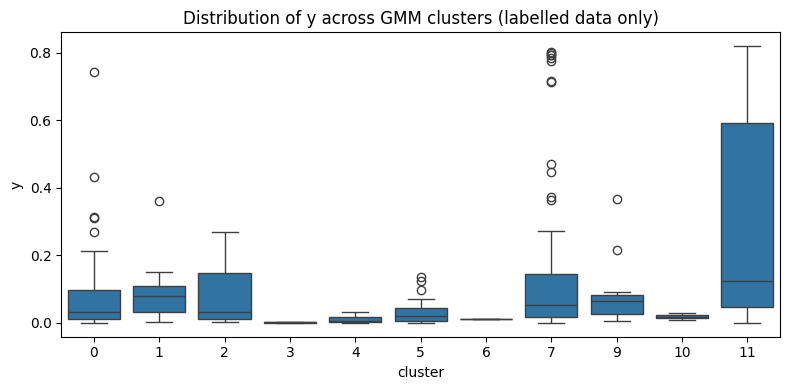

,cluster,weighted_mean_y_train
0,0,0.053471
1,1,0.096080
2,2,0.054243
3,3,0.001447
4,4,0.011008
5,5,0.032200
6,6,0.010173
7,7,0.097333
8,8,0.003000
9,9,0.042538


In [91]:
# Sanity Check: lengths must match within each split'
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print("len(X_train), len(y_train)        =", len(X_train), len(y_train))
print("len(X_validation), len(y_validation) =", len(X_validation), len(y_validation))
print("len(X_test), len(y_test)          =", len(X_test), len(y_test))
print("len(x_unlabelled)                =", len(x_unlabelled))

assert len(X_train) == len(y_train), "X_train and y_train lengths differ"
assert len(X_validation) == len(y_validation), "X_validation and y_validation lengths differ"
assert len(X_test) == len(y_test), "X_test and y_test lengths differ"

# Rebuild X_all and slices from current objects
X_all = pd.concat([X_train, X_validation, X_test, x_unlabelled], axis=0, ignore_index=True)

n_train = len(X_train)
n_val   = len(X_validation)
n_test  = len(X_test)
n_unlab = len(x_unlabelled)

idx_train = slice(0, n_train)
idx_val   = slice(n_train, n_train + n_val)
idx_test  = slice(n_train + n_val, n_train + n_val + n_test)
idx_unlab = slice(n_train + n_val + n_test, n_train + n_val + n_test + n_unlab)

print("\nX_all shape:", X_all.shape)
print("Total rows check:", n_train + n_val + n_test + n_unlab)

# Get cluster labels for X_all (hard labels)
labels_gmm = gmm.predict(X_all.values)

assert len(labels_gmm) == len(X_all), "labels_gmm length mismatch with X_all"

# Build df_all and assign y 
df_all = X_all.copy()
df_all["cluster"] = labels_gmm
df_all["y"] = np.nan

# Make y column explicitly float
df_all["y"] = pd.Series(np.nan, index=df_all.index, dtype="float64")

# Force y_* to numeric float arrays 
y_train_num = pd.to_numeric(pd.Series(np.asarray(y_train).reshape(-1)), errors="coerce").to_numpy(dtype=float)
y_val_num   = pd.to_numeric(pd.Series(np.asarray(y_validation).reshape(-1)), errors="coerce").to_numpy(dtype=float)
y_test_num  = pd.to_numeric(pd.Series(np.asarray(y_test).reshape(-1)), errors="coerce").to_numpy(dtype=float)

df_all.iloc[idx_train, df_all.columns.get_loc("y")] = np.asarray(y_train).reshape(-1)
df_all.iloc[idx_val,   df_all.columns.get_loc("y")] = np.asarray(y_validation).reshape(-1)
df_all.iloc[idx_test,  df_all.columns.get_loc("y")] = np.asarray(y_test).reshape(-1)

# Analysing y distribution per cluster (labelled only)
df_lab = df_all[df_all["y"].notna()].copy()

cluster_y_summary = (
    df_lab.groupby("cluster")["y"]
          .agg(["count", "mean", "median", "std"])
          .reset_index()
          .sort_values("cluster")
)
display(cluster_y_summary)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_lab, x="cluster", y="y")
plt.title("Distribution of y across GMM clusters (labelled data only)")
plt.tight_layout()
plt.show()

# responsibility-weighted mean y
resp_all = gmm.predict_proba(X_all.values)
K = resp_all.shape[1]

weighted_means_train = []
for k in range(K):
    w = resp_all[idx_train, k]
    y = np.asarray(y_train).reshape(-1)
    weighted_means_train.append(np.sum(w * y) / np.sum(w))

weighted_y_df = pd.DataFrame({"cluster": range(K), "weighted_mean_y_train": weighted_means_train})
display(weighted_y_df)


##### From the above results, the observed damage outcomes across GMM clusters reveals differences in damage distributions, despite damage labels not being used during clustering. 
##### In the plot, several clusters (e.g., clusters 3, 4, 6, and 10) exhibit near-zero median damage with very limited dispersion, indicating low-vulnerability building populations. 
##### In contrast, clusters such as 0, 2, and 5 display moderate damage levels with wider interquartile ranges, reflecting intermediate vulnerability regimes. 
##### Most notably, a small number of clusters, particularly clusters 7 and 11, capture highly damage-prone building populations, characterized by substantially higher medians and pronounced upper tails in the damage distribution. This pattern is further reinforced by responsibility-weighted mean damage values, where cluster 11 exhibits a markedly elevated weighted mean relative to all other clusters. 

##### This suggests that the GMM clustering provides a promising starting point for identifying latent building populations with differing vulnerability characteristics. While damage labels were not used during clustering and remain limited in number, the observed separation indicates that the clusters capture meaningful structure relevant to seismic risk analysis, which can be further refined and validated as additional labelled data become available.

In [82]:
resp_all.shape

(2022664, 12)

In [85]:
# Print out the 12 cluster means for the GMM
for k in range(gmm.n_components):
    print(f"Cluster {k} mean: {gmm.means_[k]}")

Cluster 0 mean: [-0.2525062  -0.19054687 -0.23784208 -0.07008772 -0.13676063 -0.09610986
 -0.08006729 -0.24949348 -0.08612894 -0.14426119  0.          0.
  1.        ]
Cluster 1 mean: [ 0.11439132 -0.04846246  0.05684104 -0.31673165 -0.01423531  0.04604925
 -0.20747307 -0.32164434 -0.33862836 -0.00493801  0.          0.40418467
  0.        ]
Cluster 2 mean: [ 0.89408415  0.07855153  0.81824413 -0.04108846 -0.14870778  0.28168926
 -0.12323688 -0.17315095 -0.03998363 -0.07322894  0.          0.
  1.        ]
Cluster 3 mean: [ 2.59851512  0.51565597  2.1383858  -0.40167323  0.8217815   3.14993259
 -0.40734551  0.82775843 -0.10844279  0.6301864   0.2149228   0.36430496
  0.25609486]
Cluster 4 mean: [-0.34835346  0.0922564  -0.23784208  1.12870957  0.52892994 -0.09941631
 -0.04565644  0.44409755  0.56148874  0.19219257  0.58086744  0.
  0.41913256]
Cluster 5 mean: [-0.01782173  1.64358398 -0.06070075  0.06051358  3.29013369 -0.02580048
 -0.08257242  4.15835789  0.58416157  0.50109317  0.430

### Qualitative Rank of features among Clusters

In [ ]:

feature_names = X_all.columns.tolist()
K, n_features = gmm.means_.shape

# DataFrame of means
means_df = pd.DataFrame(
    gmm.means_,
    columns=feature_names,
    index=[f"Cluster {k}" for k in range(K)]
)

# Rank features among clusters (1 = most dominant)
rank_df = means_df.abs().rank(axis=0, ascending=False, method="dense")
rank_df

,buildingheight,erabuilt,numstories,lon,lat,fparea,found_ht,ground_elv,hypo_distance,vs30,constype_RM1,constype_S1,constype_W1
Cluster 0,8.0,8.0,5.0,9.0,11.0,6.0,6.0,11.0,10.0,9.0,10.0,3.0,1.0
Cluster 1,10.0,12.0,10.0,6.0,12.0,10.0,3.0,8.0,8.0,12.0,10.0,1.0,11.0
Cluster 2,2.0,11.0,2.0,12.0,10.0,3.0,4.0,12.0,11.0,10.0,10.0,3.0,2.0
Cluster 3,1.0,5.0,1.0,5.0,6.0,1.0,2.0,4.0,9.0,3.0,9.0,2.0,10.0
Cluster 4,6.0,10.0,6.0,3.0,8.0,5.0,11.0,7.0,7.0,7.0,4.0,3.0,7.0
Cluster 5,12.0,1.0,9.0,10.0,1.0,11.0,5.0,1.0,6.0,4.0,8.0,3.0,3.0
Cluster 6,5.0,6.0,7.0,8.0,5.0,7.0,1.0,5.0,4.0,11.0,7.0,3.0,5.0
Cluster 7,11.0,9.0,12.0,11.0,9.0,9.0,9.0,10.0,12.0,8.0,1.0,3.0,11.0
Cluster 8,3.0,2.0,3.0,2.0,2.0,8.0,12.0,9.0,1.0,5.0,3.0,3.0,8.0
Cluster 9,7.0,7.0,4.0,4.0,7.0,2.0,7.0,6.0,2.0,1.0,6.0,3.0,4.0


## Summary

1. How many meaningful clusters exist in the building inventory, and how can this number be determined?

- K-means: Based on Silhouette, Calinski–Harabasz, and Davies–Bouldin scores, 6 clusters provide a good balance between separation and simplicity.

- GMM: Using AIC, BIC, log-likelihood, and geometric separation, the optimal number of components is 12.

- GMM supports more clusters because it allows overlapping and soft cluster membership.

2. Which features are the main drivers of cluster separation?

- Hypocentral distance is the most important feature for both K-means and GMM, showing that hazard exposure strongly influences clustering.

- In K-means, construction type plays a relatively minor role.

- In GMM, construction type is highly important, as the model captures correlations between building properties and hazard features.

3. Does the labeled subset show clear patterns across clusters?

- Yes. Even though damage labels were not used for clustering, the labeled buildings show differences in damage across clusters.

- Some clusters are associated with very low damage, while others show higher average damage and greater variability.

- A few clusters are missing from the labeled plots due to limited labeled data, indicating that results will improve as more labels become available.